In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [2]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS
from model.GIFT import GIFT, SklearnGIFTWrapper, MamdaniGIFT
from model.anfis import ANFIS, SklearnAnfisWrapper
from model.griffin import GRIFFIN, SklearnGRIFFINrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from train.noise import RobustnessEvaluator

In [3]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0
noise_evaluate = True

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [22]:
# datasetdec

from tests.uci_test import Cryotheraphy, Haberman, Heart, Glass, Segmentaition, Wine, Thyroid, Immunotherapy, Iris, BreastCancer, AdultIncome, BankMarketing, PimaDiabetes, CarEvaluation, Autism, Digits, DNA, MFeat# Synthetic2DGaussianClusters
from tests.class_test import Segmentation, Digits_UCI, Diabetes, BCW, Smoke # TODO try the following datasets Digits DNA
from torch.utils.data import DataLoader


#from tests.uci_test import Autism, CaliforniaHousing, Abalone
#from tests.class_test import Digits, Segmentation, Digits_UCI, Diabetes, BCW, DNA, Smoke, MNIST, ORL


experiment = DNA(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
regression = False

,Description,Value
0,Session id,199
1,Target,promoter
2,Target type,Binary
3,Original data shape,"(105, 68)"
4,Transformed data shape,"(105, 68)"
5,Transformed train set shape,"(80, 68)"
6,Transformed test set shape,"(25, 68)"
7,Numeric features,67
8,Preprocess,True
9,Imputation type,iterative


True

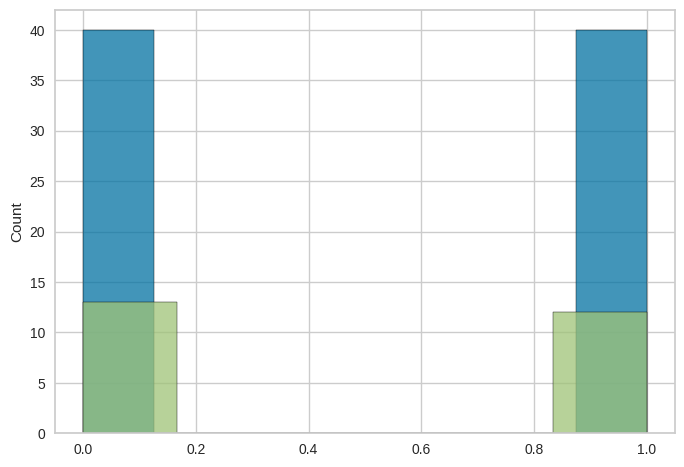

In [23]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

Noise levels:   0%|          | 0/8 [00:00<?, ?it/s]


Testing noise level: σ = 0.0

Training GIFT...
  Run 1/5... Acc=0.6000
  Run 2/5... Acc=0.6000
  Run 3/5... Acc=0.6000
  Run 4/5... Acc=0.6000
  Run 5/5... Acc=0.6000

Training LITANFIS...
  Run 1/5... Acc=0.5600
  Run 2/5... Acc=0.5600
  Run 3/5... Acc=0.5600
  Run 4/5... Acc=0.6000
  Run 5/5... 

Noise levels:  12%|█▎        | 1/8 [00:12<01:28, 12.58s/it]

Acc=0.6000

Testing noise level: σ = 0.05

Training GIFT...
  Run 1/5... Acc=0.5600
  Run 2/5... Acc=0.5600
  Run 3/5... Acc=0.6400
  Run 4/5... Acc=0.6000
  Run 5/5... Acc=0.5600

Training LITANFIS...
  Run 1/5... Acc=0.6000
  Run 2/5... Acc=0.5600
  Run 3/5... Acc=0.6400
  Run 4/5... Acc=0.5600
  Run 5/5... 

Noise levels:  25%|██▌       | 2/8 [00:21<01:01, 10.29s/it]

...

Acc=0.6000

Testing noise level: σ = 0.4

Training GIFT...
  Run 1/5... Acc=0.5600
  Run 2/5... Acc=0.6800
  Run 3/5... Acc=0.6800
  Run 4/5... Acc=0.3600
  Run 5/5... Acc=0.5600

Training LITANFIS...
  Run 1/5... Acc=0.5200
  Run 2/5... Acc=0.5600
  Run 3/5... Acc=0.6000
  Run 4/5... Acc=0.5200
  Run 5/5... 

Noise levels:  88%|████████▊ | 7/8 [01:05<00:08,  8.94s/it]

Acc=0.4000

Testing noise level: σ = 0.5

Training GIFT...
  Run 1/5... Acc=0.6000
  Run 2/5... Acc=0.6400
  Run 3/5... Acc=0.4800
  Run 4/5... Acc=0.4800
  Run 5/5... Acc=0.5600

Training LITANFIS...
  Run 1/5... Acc=0.5200
  Run 2/5... Acc=0.6000
  Run 3/5... Acc=0.4800
  Run 4/5... Acc=0.4400
  Run 5/5... 

Noise levels: 100%|██████████| 8/8 [01:17<00:00,  9.70s/it]

Acc=0.6400


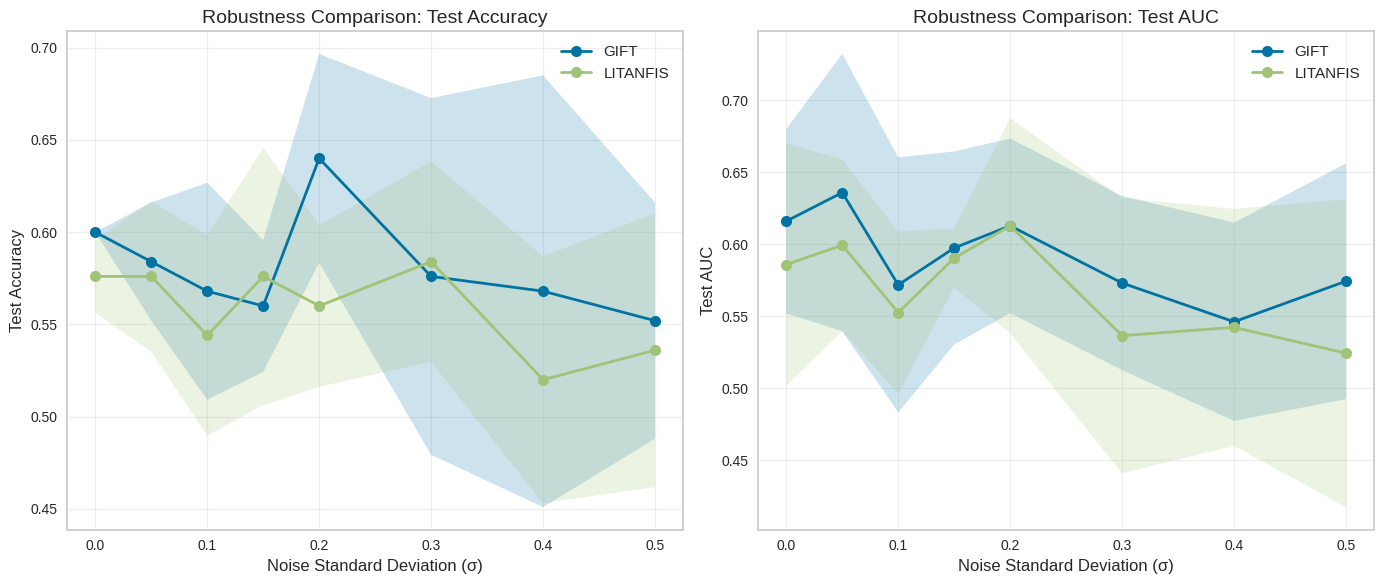

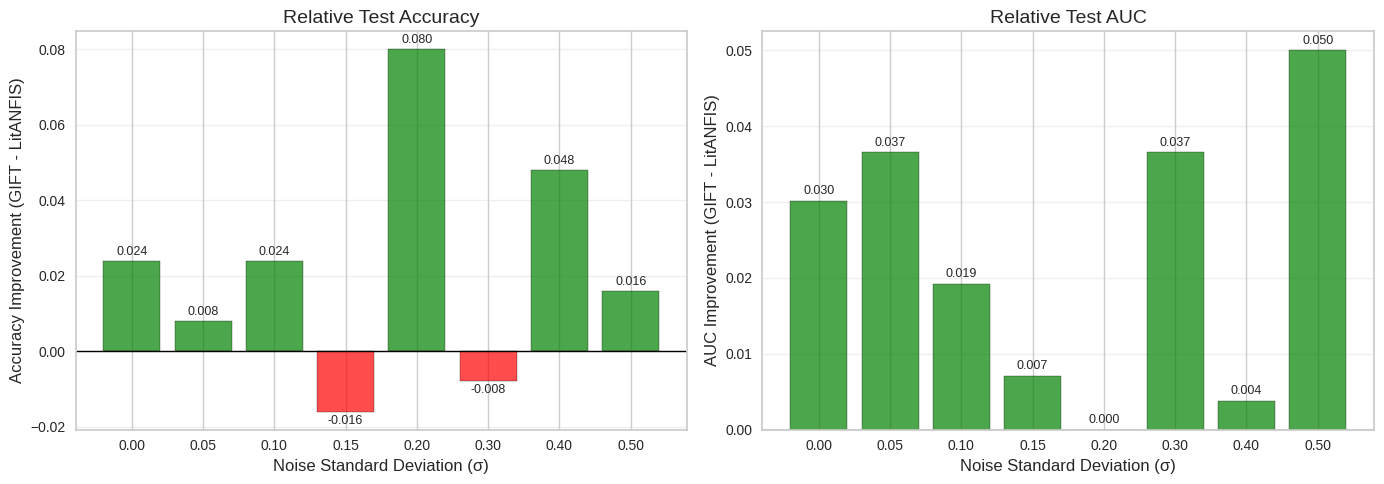


ROBUSTNESS EVALUATION REPORT
Dataset: DNA
Number of runs per noise level: 5

📊 PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
Model        Noise σ  Test Acc ± Std       Test AUC ± Std      
--------------------------------------------------------------------------------
GIFT         0.00     0.6000 ± 0.0000    0.6160 ± 0.0640
GIFT         0.05     0.5840 ± 0.0320    0.6359 ± 0.0962
GIFT         0.10     0.5680 ± 0.0588    0.5718 ± 0.0886
GIFT         0.15     0.5600 ± 0.0358    0.5974 ± 0.0670
GIFT         0.20     0.6400 ± 0.0566    0.6128 ± 0.0606
GIFT         0.30     0.5760 ± 0.0967    0.5731 ± 0.0605
GIFT         0.40     0.5680 ± 0.1170    0.5462 ± 0.0688
GIFT         0.50     0.5520 ± 0.0640    0.5744 ± 0.0819
LITANFIS     0.00     0.5760 ± 0.0196    0.5859 ± 0.0841
LITANFIS     0.05     0.5760 ± 0.0408    0.5994 ± 0.0597
LITANFIS     0.10     0.5440 ± 0.0543    0.5526 ± 0.0564
LITANFIS     0.15     0.5760 ± 0.0697    0.590

In [24]:
# Configure evaluator
evaluator = RobustnessEvaluator(
    experiment=experiment,
    model_params_gift={
        'in_features': experiment.train_numpy()[0].shape[1],
        'out_features': len(np.unique(experiment.train_numpy()[1])),
        'rules': 2,
        'drop_out_p': 0.3,
        'binary' : binary,
        'zeta': 1.0
    },
    model_params_litanfis={
        'in_features': experiment.train_numpy()[0].shape[1],
        'out_features': len(np.unique(experiment.train_numpy()[1])),
        'rules': 2,
        'drop_out_p': 0.3,
        'binary': binary
    },
    learning_params={
        'batch_size': 32,
        'lr': 0.005,
        'max_lr': 0.01,
        'epochs': 100,
        'alpha': 1.0,
        'min_alpha': 0.0
    },
    device=device,
    binary=binary,
    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    n_runs=5,
    random_state=42
)

# Run evaluation
results_df = evaluator.evaluate(verbose=True)

# Plot results
evaluator.plot_robustness_curves(save_path='robustness_curves.png')
evaluator.plot_relative_performance(save_path='relative_performance.png')

# Print detailed report
evaluator.print_detailed_report()

# Get just the best model
best_model, details = evaluator.get_best_model()
print(f"Best model: {best_model}")
print(f"Details: {details}")

In [25]:
# prepare the model - modeldec

from train.early_stop import EarlyStopping

model_params = {
    'type': "gift", # anfis, unfis, gift, litanfis, gift-mamdani, griffin
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 2,
    'drop_out_p': 0.3,
    'binary' : binary,
    #'rank': 2,
    #'eta':1  
}
zeta = 1.0
rank = 2
eta = 1 
Xi = 1


model_type = model_params.pop('type')

if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32, zeta=zeta)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "gift-mamdani":
    model = MamdaniGIFT(**model_params, dtype=torch.float32, zeta=zeta)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "griffin":
    model = GRIFFIN(**model_params, dtype=torch.float32, zeta=1, rank=rank, eta=eta, Xi=Xi, regression=regression)
    sk_model = SklearnGRIFFINrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift")


optimizer = optim.Adam(model.parameters(), lr=lr)

steps_per_epoch=len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)

# Early stopping    
early_stopping = EarlyStopping(patience=10, delta=-0.00001)

alpha_decaying = np.power(min_alpha / alpha, (steps_per_epoch * epochs/2))

cos = nn.L1Loss()

if binary:
    cross = nn.BCEWithLogitsLoss()
    
    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs.squeeze(), batch_y.squeeze()) + cos(reconstructed, batch_X) * alpha 

else:
    cross = nn.CrossEntropyLoss()

    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs, batch_y.long()) + cos(reconstructed, batch_X) * alpha 

In [ ]:
# train

import random
from train.noise import add_gaussian_noise


def set_random_state(seed: int | None = None):
    if seed is None:
        # Generate a random seed from system entropy
        seed = np.random.randint(0, 2**32 - 1)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    return seed

set_random_state()

history = []

for epoch in range(epochs):
    
    model.train()
    train_loss = 0

    if model_type == 'gift' or model_type == "litanfis":
        stats = model.get_interpretable_params()
        stats["epoch"] = epoch
        history.append(stats)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: {stats}")

    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs, reconstructed, entropy = model(batch_X)

        loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha)
        total_loss = loss
        total_loss.backward()
        optimizer.step()
        
        # Step the scheduler, but ignore the "exceeded total steps" error
        try:
            scheduler.step()
        except ValueError as e:
            if "Tried to step" in str(e) and "total steps" in str(e):
                # Reached the end of the scheduled steps; no further adjustments needed
                pass
            else:
                raise
    
    alpha *= alpha_decaying
    train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)
        
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            output, _, _ = model(data)
            
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())

            val_loss += loss.item() * data.size(0)

    val_loss /= len(test_loader.dataset)

    print(
        f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break
    
early_stopping.load_best_model(model)

Epoch 0: {'literal_mean': 0.4939132332801819, 'literal_std': 0.02924862504005432, 'temp_mean': 0.5008938908576965, 'temp_std': 0.03393099829554558, 'weight_mean': 0.4983178675174713, 'weight_std': 0.017205828800797462, 'relax_mean': 0.5, 'relax_std': 0.0, 'literal_saturation': 0.0, 'temp_saturation': 0.0, 'weight_saturation': 0.0, 'relax_saturation': 0.0, 'epoch': 0}
Epoch 1, Train Loss: 0.2778, Val Loss: 1.1956
Epoch 2, Train Loss: 0.1629, Val Loss: 1.1914
Epoch 3, Train Loss: 0.1723, Val Loss: 1.1864
Epoch 4, Train Loss: 0.1647, Val Loss: 1.1799
Epoch 5, Train Loss: 0.1645, Val Loss: 1.1717
Epoch 6, Train Loss: 0.1548, Val Loss: 1.1615
Epoch 7, Train Loss: 0.1632, Val Loss: 1.1490
Epoch 8, Train Loss: 0.1616, Val Loss: 1.1335
Epoch 9, Train Loss: 0.1654, Val Loss: 1.1154
Epoch 10, Train Loss: 0.1596, Val Loss: 1.0937
Epoch 10: {'literal_mean': 0.49682021141052246, 'literal_std': 0.028742557391524315, 'temp_mean': 0.49669361114501953, 'temp_std': 0.03578915446996689, 'weight_mean': 0.

In [10]:
%matplotlib inline  
experiment.evaluate_model(sk_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [11]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters


from sklearn.metrics import classification_report, roc_auc_score
import pprint
import numpy as np

# Get raw labels (might be 1D or one‑hot)
y_train_raw = experiment.train_numpy()[1]
y_test_raw  = experiment.test_numpy()[1]

# Convert to 1D if necessary
if y_train_raw.ndim == 2:
    y_train = np.argmax(y_train_raw, axis=1)
    y_test  = np.argmax(y_test_raw, axis=1)
else:
    y_train = y_train_raw
    y_test  = y_test_raw

# Get predicted probabilities
y_train_proba = sk_model.predict_proba(experiment.train_numpy()[0])
y_test_proba  = sk_model.predict_proba(experiment.test_numpy()[0])

# For binary classification, roc_auc_score expects probability of the positive class
if binary:
    # If probabilities have 2 columns, take the second column (positive class)
    if y_train_proba.shape[1] == 2:
        y_train_proba_bin = y_train_proba[:, 1]
        y_test_proba_bin  = y_test_proba[:, 1]
    else:
        y_train_proba_bin = y_train_proba[:, 0]
        y_test_proba_bin  = y_test_proba[:, 0]
    train_auc = roc_auc_score(y_train, y_train_proba_bin)
    test_auc  = roc_auc_score(y_test,  y_test_proba_bin)
else:
    train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
    test_auc  = roc_auc_score(y_test,  y_test_proba, multi_class='ovr')

# Build result string
result = ""
result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(y_train, sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(y_test, sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)

Experiment Result Thyroid
------ train ------
              precision    recall  f1-score   support

           0     0.9211    1.0000    0.9589       105
           1     1.0000    0.8333    0.9091        24
           2     1.0000    0.7619    0.8649        21

    accuracy                         0.9400       150
   macro avg     0.9737    0.8651    0.9110       150
weighted avg     0.9447    0.9400    0.9378       150
AUC	0.9889957343833314
------ test ------
              precision    recall  f1-score   support

           0     0.9000    1.0000    0.9474        45
           1     1.0000    0.7273    0.8421        11
           2     1.0000    0.7778    0.8750         9

    accuracy                         0.9231        65
   macro avg     0.9667    0.8350    0.8882        65
weighted avg     0.9308    0.9231    0.9195        65
AUC	0.9971164021164021
{'binary': False,
 'drop_out_p': 0.3,
 'in_features': 5,
 'out_features': 3,
 'rules': 2}
{'alpha': 1.0,
 'batch_size': 32,
 'epo

In [12]:
with open(f'results/{model_type}_{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

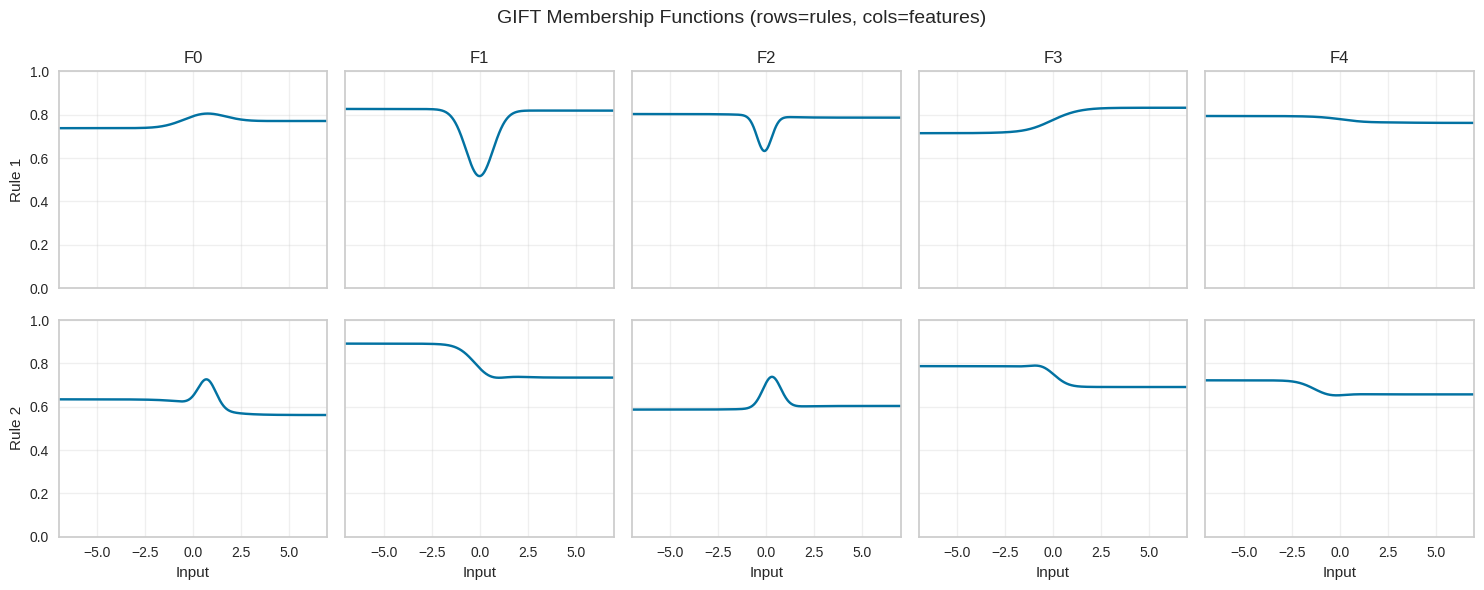

In [13]:
# plot the membership functions
from model.mf_plot import plot_litanfis_mfs, plot_gift_mfs, plot_gift_param_progress
if model_type == "gift":
    X_train_np, y_train_np = experiment.train_numpy() 
    plot_gift_mfs(model, feature_names=None)


if model_type == 'litanfis':
    X_train_np, y_train_np = experiment.train_numpy()
    plot_litanfis_mfs(model, feature_names=None)


In [14]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance
'''import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()'''


'import numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import roc_curve, auc, RocCurveDisplay\nfrom sklearn.preprocessing import label_binarize\n\nX_test, y_test = experiment.test_numpy()\ny_score = sk_model.predict_proba(X_test)\n\nclasses = np.unique(y_test)\nn_classes = len(classes)\n\nplt.figure(figsize=(8, 8), dpi=200)\n\n# Binary classification\nif n_classes == 2:\n    # Determine which column(s) to use\n    if y_score.shape[1] == 2:\n        # Standard case: two columns, second is probability of positive class\n        y_score_bin = y_score[:, 1]\n    elif y_score.shape[1] == 1:\n        # Single column: assume it\'s probability of the positive class\n        y_score_bin = y_score[:, 0]\n    else:\n        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")\n\n    fpr, tpr, _ = roc_curve(y_test, y_score_bin)\n    roc_auc = auc(fpr, tpr)\n\n    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,\n                    estimator_name=\'Binary classifier